In [4]:
import torch
import torch.nn as nn

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [33]:
!nvidia-smi

Mon Jun  8 23:51:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.43.02              KMD Version: 610.47        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 5070        On  |   00000000:01:00.0  On |                  N/A |
|  0%   59C    P0             30W /  250W |    2791MiB /  12227MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
class GeomagneticModelV1(nn.Module):
    def __init__(
        self,
        lstm_input_size,
        lstm_hidden_size,
        lstm_num_layers,
        lstm_dropout,
        dst_attention_heads,
        ae_attention_heads,
        forecasts_len,
    ):
        super().__init__()

        self.dst_attention = nn.MultiheadAttention(
            lstm_input_size,
            dst_attention_heads,
            dropout=lstm_dropout,
            batch_first=True,
        )
        self.dst_attention_norm = nn.LayerNorm(lstm_input_size)
        self.ae_attention = nn.MultiheadAttention(
            lstm_input_size, ae_attention_heads, dropout=lstm_dropout, batch_first=True
        )
        self.ae_attention_norm = nn.LayerNorm(lstm_input_size)

        self.dst_lstm = nn.LSTM(
            lstm_input_size,
            lstm_hidden_size,
            lstm_num_layers,
            dropout=lstm_dropout,
            batch_first=True,
        )
        self.ae_lstm = nn.LSTM(
            lstm_input_size,
            lstm_hidden_size,
            lstm_num_layers,
            dropout=lstm_dropout,
            batch_first=True,
        )

        self.dropout = nn.Dropout(lstm_dropout)
        heads_hidden_size = lstm_hidden_size

        self.dst_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, forecasts_len),
        )

        self.ae_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, forecasts_len),
        )

    def forward(self, x):
        dst_attn_out, dst_attn_w = self.dst_attention(x, x, x)
        dst_x = self.dst_attention_norm(x + dst_attn_out)
        dst_out, _ = self.dst_lstm(dst_x)
        dst_features = self.dropout(dst_out[:, -1, :])
        dst = self.dst_head(dst_features)

        ae_attn_out, ae_attn_w = self.ae_attention(x, x, x)
        ae_x = self.ae_attention_norm(x + ae_attn_out)
        ae_out, _ = self.ae_lstm(ae_x)
        ae_features = self.dropout(ae_out[:, -1, :])
        ae = self.ae_head(ae_features)

        return dst, ae, (dst_attn_w, ae_attn_w)

In [8]:
model = GeomagneticModelV1(
    lstm_input_size=14,
    lstm_hidden_size=64,
    lstm_num_layers=2,
    lstm_dropout=0.2,
    dst_attention_heads=2,
    ae_attention_heads=2,
    forecasts_len=6,
)
model.load_state_dict(torch.load("/home/zorinep/workdir/magnesis/notebooks/examples/weights/GN_best.pt"))
model.to(device)

GeomagneticModelV1(
  (dst_attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=14, out_features=14, bias=True)
  )
  (dst_attention_norm): LayerNorm((14,), eps=1e-05, elementwise_affine=True, bias=True)
  (ae_attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=14, out_features=14, bias=True)
  )
  (ae_attention_norm): LayerNorm((14,), eps=1e-05, elementwise_affine=True, bias=True)
  (dst_lstm): LSTM(14, 64, num_layers=2, batch_first=True, dropout=0.2)
  (ae_lstm): LSTM(14, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (dst_head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.1)
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=6, bias=True)
  )
  (ae_head): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): LeakyReLU(negative_slope=0.1)

In [10]:
class GeomagneticDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        X,
        y,
        X_window_size: int,
        y_window_size: int,
        stride: int = 1,
    ):
        self.X = torch.FloatTensor(X) if not isinstance(X, torch.Tensor) else X
        self.y = torch.FloatTensor(y) if not isinstance(y, torch.Tensor) else y
        self.X_window_size = X_window_size
        self.y_window_size = y_window_size
        self.stride = stride

        assert len(self.X) == len(self.y), "X and y must have same length"

        total_window = X_window_size + y_window_size
        self.num_samples = (len(self.X) - total_window) // stride + 1
        assert self.num_samples > 0, "Not enough data for windows"

    def __len__(self) -> int:
        return self.num_samples

    def __getitem__(self, index):
        start_idx = index * self.stride

        x_end_idx = start_idx + self.X_window_size
        x_window = self.X[start_idx:x_end_idx]

        y_start_idx = x_end_idx
        y_end_idx = y_start_idx + self.y_window_size
        y_window = self.y[y_start_idx:y_end_idx]  # [y_window_size, 2]

        return x_window, y_window

In [11]:
def make_dataset(
    path,
    x_scaler,
    y_scaler,
    X_window_size=24*7,
    y_window_size=6,
    batch_size=32,
    stride=6,
):
  dataset = pd.read_csv(path)
  dataset = dataset.drop(columns=["Unnamed: 0"])
  dataset['datetime'] = pd.to_datetime(
      dataset['Year'].astype(str) + '-' +
      dataset['Decimal Day'].astype(str) +
      ' ' +
      dataset['Hour'].astype(str),
      format='%Y-%j %H'
  )
  dataset = dataset.drop(columns=["Year", "Decimal Day", "Hour"])
  cols = ['datetime'] + [col for col in dataset.columns if col != 'datetime']
  dataset = dataset[cols]

  fill_values = {
      "Bz_GSM": 999.9,
      "By_GSM": 999.9,
      "Bx_GSE": 999.9,
      "Kp": 99,
      "f10.7": 999.9,
      "AL": 99999,
      "AU": 99999,
      "T_proton": 9999999.,
      "Np_density": 999.9,
      "V_plasma": 9999.,
      "V_Long_GSE": 999.9,
      "V_Lat_GSE": 999.9,
      "Dst": 99999,
      "AE": 9999,
  }
  for col in dataset.drop(columns=["datetime"]).columns:
      dataset[col] = dataset[col].replace(fill_values[col], np.nan)

  clean_dataset = dataset.copy()
  features = [i for i in clean_dataset.columns if i != "datetime"]
  clean_dataset[features] = clean_dataset[features].interpolate(method="pchip")

  dataset_to_preprocess = clean_dataset.copy()

  X_test, y_test = dataset_to_preprocess.drop(columns=["datetime"]), dataset_to_preprocess[["Dst", "AE"]]

  X_test_scaled = x_scaler.transform(X_test)

  y_test_scaled = y_scaler.transform(y_test)
  test_dataset = GeomagneticDataset(
      X=X_test_scaled,
      y=y_test_scaled,
      X_window_size=X_window_size,
      y_window_size=y_window_size,
      stride=stride,
  )
  val_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
  return val_loader

In [13]:
X_scaler = joblib.load("/home/zorinep/workdir/magnesis/notebooks/examples/weights/GN_X_scaler.joblib")
y_scaler = joblib.load("/home/zorinep/workdir/magnesis/notebooks/examples/weights/GN_y_scaler.joblib")
BATCH_SIZE = 256
STRIDE = 1

loader_by_2019 = make_dataset(
    path="../../../data/datasets/test_2019.csv",
    x_scaler=X_scaler,
    y_scaler=y_scaler,
    X_window_size=168,
    y_window_size=6,
    batch_size=BATCH_SIZE,
    stride=STRIDE,
)
loader_by_2025 = make_dataset(
    path="../../../data/datasets/test_2025.csv",
    x_scaler=X_scaler,
    y_scaler=y_scaler,
    X_window_size=168,
    y_window_size=6,
    batch_size=BATCH_SIZE,
    stride=STRIDE,
)

In [26]:
def visualize_6th_hour_predictions(model, loader, y_scaler, device='cuda', title_prefix='', until = -1):
    dst_labels_6h = []
    dst_preds_6h = []
    ae_labels_6h = []
    ae_preds_6h = []

    with torch.no_grad():
        model.eval()
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            dst_pred, ae_pred, _ = model(x)
            
            dst_pred_6h = dst_pred[:, -1].cpu().numpy()
            ae_pred_6h = ae_pred[:, -1].cpu().numpy()
            
            dst_true_6h = y[:, -1, 0].cpu().numpy()
            ae_true_6h = y[:, -1, 1].cpu().numpy()
            
            dst_preds_6h.extend(dst_pred_6h)
            ae_preds_6h.extend(ae_pred_6h)
            dst_labels_6h.extend(dst_true_6h)
            ae_labels_6h.extend(ae_true_6h)
    
    dst_preds_6h = np.array(dst_preds_6h)
    ae_preds_6h = np.array(ae_preds_6h)
    dst_labels_6h = np.array(dst_labels_6h)
    ae_labels_6h = np.array(ae_labels_6h)
    
    dst_pred_scaled = dst_preds_6h.reshape(-1, 1)
    dst_true_scaled = dst_labels_6h.reshape(-1, 1)
    
    ae_pred_scaled = ae_preds_6h.reshape(-1, 1)
    ae_true_scaled = ae_labels_6h.reshape(-1, 1)
    
    preds_combined = np.hstack([dst_pred_scaled, ae_pred_scaled])
    true_combined = np.hstack([dst_true_scaled, ae_true_scaled])
    
    preds_original = y_scaler.inverse_transform(preds_combined)
    true_original = y_scaler.inverse_transform(true_combined)
    
    dst_preds_orig = preds_original[:, 0][:until]
    ae_preds_orig = preds_original[:, 1][:until]
    dst_labels_orig = true_original[:, 0][:until]
    ae_labels_orig = true_original[:, 1][:until]
    
    dst_rmse = np.sqrt(np.mean((dst_labels_orig - dst_preds_orig) ** 2))
    dst_mae = np.mean(np.abs(dst_labels_orig - dst_preds_orig))
    ae_rmse = np.sqrt(np.mean((ae_labels_orig - ae_preds_orig) ** 2))
    ae_mae = np.mean(np.abs(ae_labels_orig - ae_preds_orig))
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Dst
    axes[0].plot(dst_labels_orig, label='Истинные значения', color='#1f77b4', linewidth=1, alpha=0.8)
    axes[0].plot(dst_preds_orig, label='Прогноз (6 часов вперёд)', color='#ff7f0e', linewidth=1, alpha=0.8)
    axes[0].set_title(f'{title_prefix} Dst (прогноз на 6 часов)', fontsize=12)
    axes[0].set_xlabel('Временные шаги (часы)')
    axes[0].set_ylabel('Dst, nT')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    axes[0].text(0.02, 0.95, f'RMSE = {dst_rmse:.2f} nT\nMAE = {dst_mae:.2f} nT', 
                 transform=axes[0].transAxes, fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    # AE
    axes[1].plot(ae_labels_orig, label='Истинные значения', color='#1f77b4', linewidth=1, alpha=0.8)
    axes[1].plot(ae_preds_orig, label='Прогноз (6 часов вперёд)', color='#ff7f0e', linewidth=1, alpha=0.8)
    axes[1].set_title(f'{title_prefix} AE (прогноз на 6 часов)', fontsize=12)
    axes[1].set_xlabel('Временные шаги (часы)')
    axes[1].set_ylabel('AE, nT')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    axes[1].text(0.02, 0.95, f'RMSE = {ae_rmse:.2f} nT\nMAE = {ae_mae:.2f} nT', 
                 transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    plt.suptitle(f'{title_prefix} Прогноз геомагнитных индексов на 6 часов вперёд (stride=1)', fontsize=14)
    plt.tight_layout()
    plt.show()
    print(f"{title_prefix} Результаты прогноза на 6 часов вперёд")
    print(f"Dst: RMSE = {dst_rmse:.2f} nT, MAE = {dst_mae:.2f} nT")
    print(f"AE:  RMSE = {ae_rmse:.2f} nT, MAE = {ae_mae:.2f} nT")
    
    return {
        'dst_rmse': dst_rmse,
        'dst_mae': dst_mae,
        'ae_rmse': ae_rmse,
        'ae_mae': ae_mae,
        'dst_preds': dst_preds_orig,
        'dst_labels': dst_labels_orig,
        'ae_preds': ae_preds_orig,
        'ae_labels': ae_labels_orig,
    }

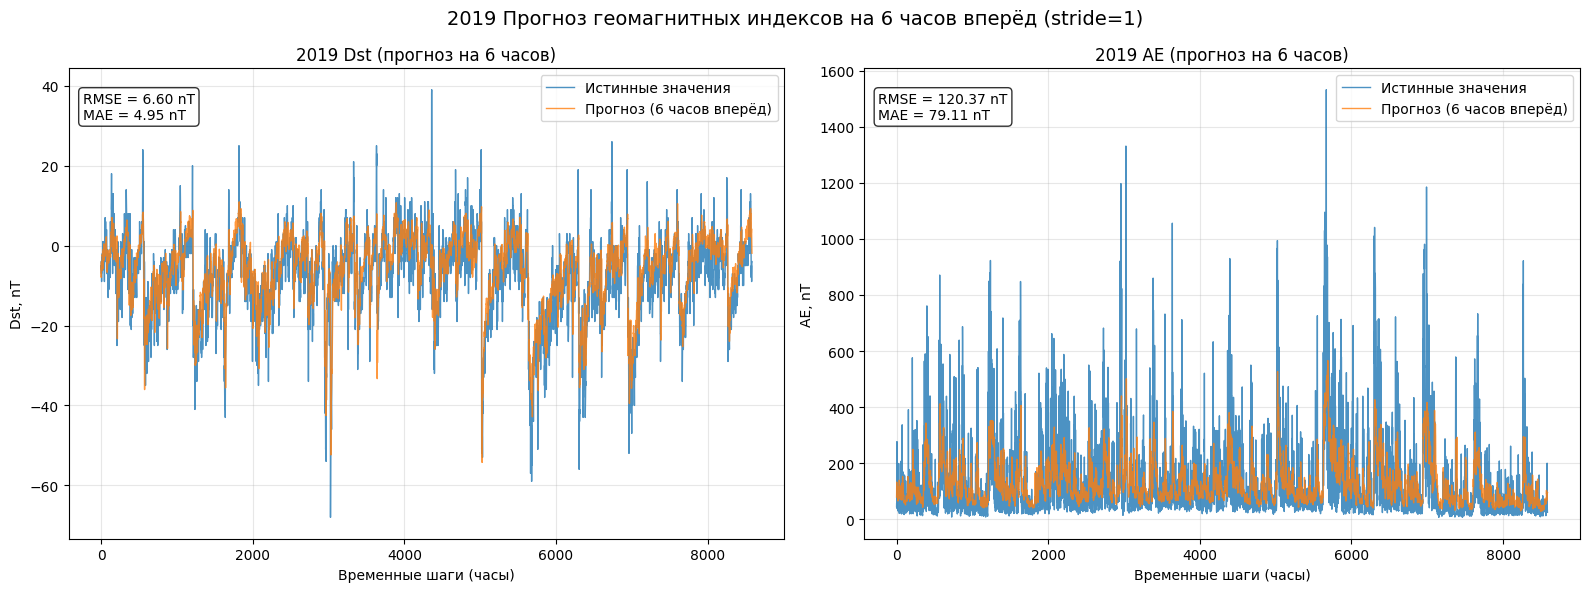

2019 Результаты прогноза на 6 часов вперёд
Dst: RMSE = 6.60 nT, MAE = 4.95 nT
AE:  RMSE = 120.37 nT, MAE = 79.11 nT


In [27]:
result_2019 = visualize_6th_hour_predictions(
    model, loader_by_2019, y_scaler, device='cuda', title_prefix='2019'
)

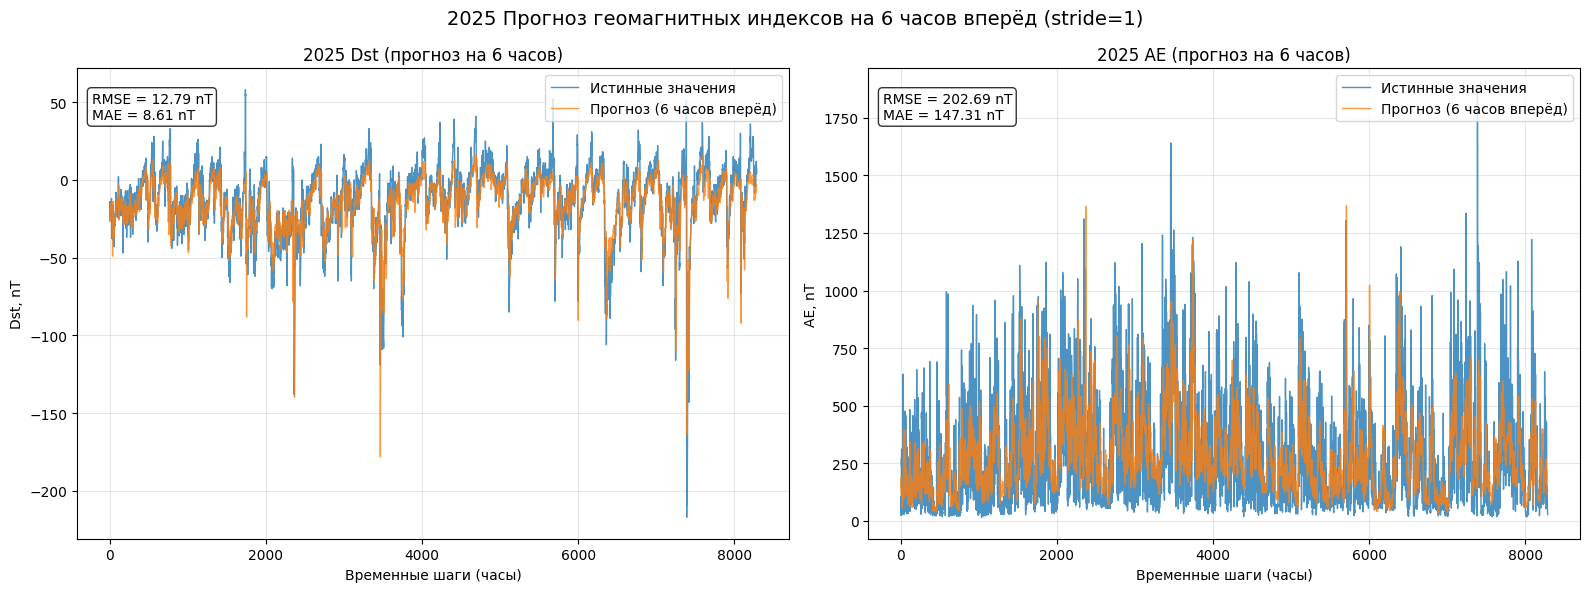

2025 Результаты прогноза на 6 часов вперёд
Dst: RMSE = 12.79 nT, MAE = 8.61 nT
AE:  RMSE = 202.69 nT, MAE = 147.31 nT


In [32]:
result_2025 = visualize_6th_hour_predictions(
    model, loader_by_2025, y_scaler, device='cuda', title_prefix='2025', until=-300
)